In [2]:
import os
import shutil
import csv
import datetime
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, MaxPooling2D, MaxPool2D,
    BatchNormalization, Activation, ReLU,
    GlobalAveragePooling2D, Flatten,
    Dense, Dropout, Add, Multiply, Reshape, Concatenate, AveragePooling2D
)
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanSquaredError
from tensorflow.keras.regularizers import l2

In [3]:
src_path = "/kaggle/input/uktfaces-imdb-wiki-10-70/downsampled" # age from 10 - 70
dst_base_path = "/kaggle/working/data"

os.makedirs(dst_base_path, exist_ok=True)

In [4]:
# Xóa file CSV và log cũ nếu tồn tại
csv_file_path = os.path.join(dst_base_path, "image_info.csv")
skipped_log_path = os.path.join(dst_base_path, "skipped_files.txt")
if os.path.exists(csv_file_path):
    os.remove(csv_file_path)
    print(f"Deleted existing CSV: {csv_file_path}")
if os.path.exists(skipped_log_path):
    os.remove(skipped_log_path)
    print(f"Deleted existing log: {skipped_log_path}")

Deleted existing CSV: /kaggle/working/data/image_info.csv


In [5]:
# Mở file CSV để ghi
with open(csv_file_path, mode='w', newline='', encoding='utf-8') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["index", "path", "age"])
    writer.writeheader()

    index = 0
    for img_name in tqdm(os.listdir(src_path), desc="Parsing image info"):
        if not img_name.endswith(('.jpg', '.jpeg', '.png', '.jpg.chip.jpg')):
            continue
        try:
            age_str = img_name.split("_")[0]
            age_int = int(age_str)

            img_path = os.path.join(src_path, img_name)

            writer.writerow({
                "index": index,
                "path": img_path,
                "age": age_int
            })
            index += 1
        except Exception as e:
            print(f"Skipping {img_name}: {e}")

Parsing image info: 100%|██████████| 51298/51298 [00:00<00:00, 174275.15it/s]


In [6]:
df = pd.read_csv("/kaggle/working/data/image_info.csv")
unique_ages = df['age'].unique()
# Sắp xếp các giá trị duy nhất theo thứ tự tăng dần
unique_ages_sorted = sorted(unique_ages)
# In ra danh sách các độ tuổi duy nhất
print("Các độ tuổi duy nhất trong file CSV:")
print(unique_ages_sorted)
# In số lượng độ tuổi duy nhất
print(f"Tổng số độ tuổi duy nhất: {len(unique_ages_sorted)}")

Các độ tuổi duy nhất trong file CSV:
[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]
Tổng số độ tuổi duy nhất: 61


In [7]:
print(df.head())

   index                                               path  age
0      0  /kaggle/input/uktfaces-imdb-wiki-10-70/downsam...   65
1      1  /kaggle/input/uktfaces-imdb-wiki-10-70/downsam...   46
2      2  /kaggle/input/uktfaces-imdb-wiki-10-70/downsam...   29
3      3  /kaggle/input/uktfaces-imdb-wiki-10-70/downsam...   56
4      4  /kaggle/input/uktfaces-imdb-wiki-10-70/downsam...   30


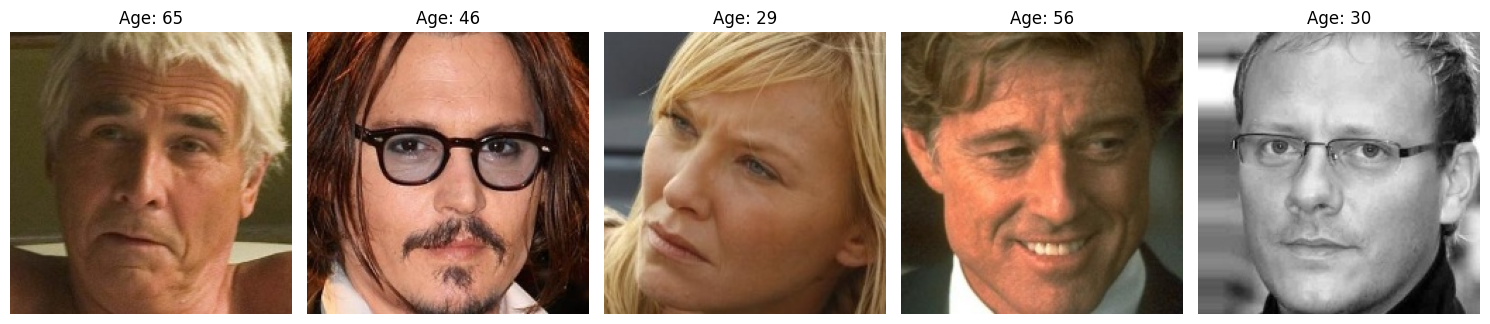

In [8]:
df_top5 = df.head(5)

# Kiểm tra xem DataFrame có dữ liệu không
if len(df_top5) == 0:
    print("DataFrame rỗng, không có ảnh để hiển thị.")
else:
    plt.figure(figsize=(15, 7))
    
    for i, (index, row) in enumerate(df_top5.iterrows()):
        img_path = row['path']
        age_label = row['age']
        
        if not os.path.exists(img_path):
            print(f"Không tìm thấy ảnh tại: {img_path}")
            continue
        
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Không thể đọc ảnh {img_path}: {e}")
            continue
        
        # Tạo subplot (1 hàng, 5 cột)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"Age: {age_label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

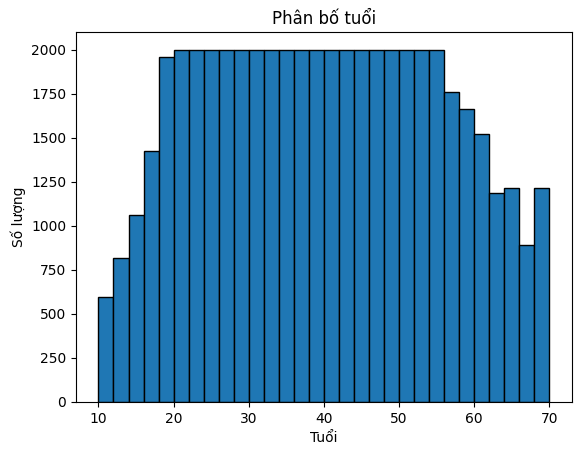

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['age'], bins=30, edgecolor='black')
plt.title('Phân bố tuổi')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.show()

In [11]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    brightness_range=[0.8, 1.2],
    zoom_range=0.3,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='age',
    target_size=(128, 128),
    batch_size=64,
    class_mode='raw',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='age',
    target_size=(128, 128),
    batch_size=64,
    class_mode='raw',
    shuffle=True,
    seed=42
)

Found 41038 validated image filenames.
Found 10260 validated image filenames.


In [14]:
# Dense Layer
def dense_layer(x, growth_rate):
    """1 Bottleneck layer: BN -> ReLU -> 1x1 Conv -> BN -> ReLU -> 3x3 Conv"""
    bn1 = BatchNormalization()(x)
    act1 = Activation('relu')(bn1)
    conv1 = Conv2D(4 * growth_rate, kernel_size=1, padding='same', use_bias=False)(act1)

    bn2 = BatchNormalization()(conv1)
    act2 = Activation('relu')(bn2)
    conv2 = Conv2D(growth_rate, kernel_size=3, padding='same', use_bias=False)(act2)

    return conv2

# Dense Block
def dense_block(x, num_layers, growth_rate):
    concat_feat = x
    for _ in range(num_layers):
        layer_out = dense_layer(concat_feat, growth_rate)
        concat_feat = Concatenate()([concat_feat, layer_out])
    return concat_feat

# Transition Layer
def transition_layer(x, reduction=0.5):
    bn = BatchNormalization()(x)
    act = Activation('relu')(bn)
    out_channels = int(tf.keras.backend.int_shape(x)[-1] * reduction)
    conv = Conv2D(out_channels, kernel_size=1, padding='same', use_bias=False)(act)
    pool = AveragePooling2D(pool_size=2, strides=2, padding='same')(conv)
    return pool

# DenseNet Regression Model DenseNet-121
def build_densenet_regression(input_shape=(128, 128, 3), growth_rate=32): # growth_rate = 32 theo mặc định, bạn có thể giảm còn 16 hoặc 12 nếu model quá nặng
    inputs = Input(shape=input_shape)

    # Initial Convolution
    x = Conv2D(64, kernel_size=7, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D(pool_size=3, strides=2, padding='same')(x)

    # Dense Blocks
    x = dense_block(x, num_layers=6, growth_rate=growth_rate)  # Block 1
    x = transition_layer(x)

    x = dense_block(x, num_layers=12, growth_rate=growth_rate)  # Block 2
    x = transition_layer(x)

    x = dense_block(x, num_layers=24, growth_rate=growth_rate)  # Block 3
    x = transition_layer(x)

    x = dense_block(x, num_layers=16, growth_rate=growth_rate)  # Block 4

    # Classification Head
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    output = Dense(1, activation='linear')(x)

    model = Model(inputs=inputs, outputs=output, name='DenseNet_Regression')

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='huber',  # Huber loss ổn định với outlier
        metrics=['mae', 'mse']
    )
    return model

In [15]:
# # Tạo mô hình
# model = build_agenet()
# model.summary()
model = build_densenet_regression(input_shape=(128, 128, 3),growth_rate=16)
model.summary()

I0000 00:00:1747759677.620415      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747759677.621104      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "DenseNet_Regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 64)     │          9,408 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 64, 64, 64)     │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 64, 64, 64)     │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average_pooling2d         │ (None, 32, 32, 64)     │              0 │ activation[0][0]       │
│ (AveragePooling2D)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 32, 32, 64)     │            256 │ average_pooling2d[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 32, 32, 64)     │          4,096 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 32, 32, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 32, 32, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 16)     │          9,216 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32, 32, 80)     │              0 │ average_pooling2d[0][… │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 32, 32, 80)     │            320 │ concatenate[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 32, 32, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 64)     │          5,120 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 32, 32, 64)     │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 1,865,621 (7.12 MB)

 Trainable params: 1,822,333 (6.95 MB)

 Non-trainable params: 43,288 (169.09 KB)

In [16]:
from tensorflow.keras.losses import Huber

model = load_model("/kaggle/working/data/best_model.h5",custom_objects={"Huber":Huber})

In [17]:
model.compile(
    optimizer='adam',
    loss=Huber(delta=1.0),
    metrics=['mae', 'mse']
)


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/data/best_model.h5',           
    monitor='val_loss',                 
    save_best_only=True,               
    save_weights_only=False,           
    mode='min',                        
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [42]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    # steps_per_epoch=train_generator.samples // train_generator.batch_size,
    # validation_staeps=val_generator.samples // val_generator.batch_size,
    callbacks=[checkpoint,early_stop,reduce_lr]
)

Epoch 1/50
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - loss: 13.6347 - mae: 14.1278 - mse: 294.2516

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 11.61342, saving model to /kaggle/working/data/best_model.h5
642/642 ━━━━━━━━━━━━━━━━━━━━ 613s 955ms/step - loss: 13.6332 - mae: 14.1263 - mse: 294.1845 - val_loss: 11.6134 - val_mae: 12.1056 - val_mse: 214.4854 - learning_rate: 0.0010
Epoch 2/50
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 11.9260 - mae: 12.4178 - mse: 226.3986
Epoch 2: val_loss did not improve from 11.61342
642/642 ━━━━━━━━━━━━━━━━━━━━ 245s 381ms/step - loss: 11.9258 - mae: 12.4177 - mse: 226.3948 - val_loss: 12.1894 - val_mae: 12.6819 - val_mse: 234.5028 - learning_rate: 0.0010
Epoch 3/50
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 11.3216 - mae: 11.8135 - mse: 212.0614
Epoch 3: val_loss improved from 11.61342 to 10.69680, saving model to /kaggle/working/data/best_model.h5
642/642 ━━━━━━━━━━━━━━━━━━━━ 245s 381ms/step - loss: 11.3214 - mae: 11.8132 - mse: 212.0542 - val_loss: 10.6968 - val_mae: 11.1878 - val_mse: 186.4798 - learning_rate: 0.0010
Epoch 4/50
642/642 

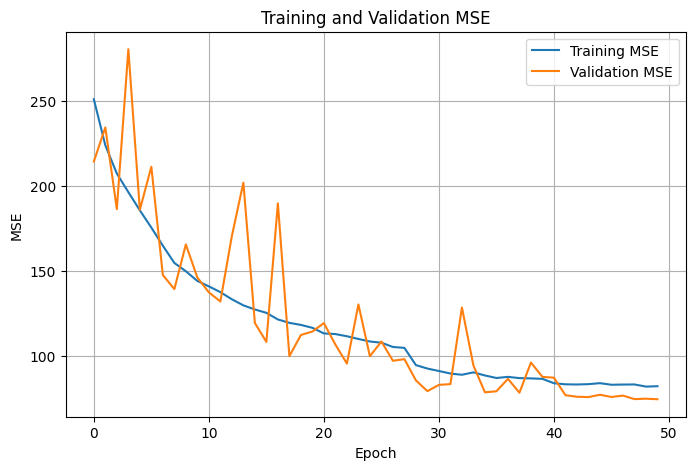

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Training and Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()


In [19]:
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    # steps_per_epoch=train_generator.samples // train_generator.batch_size,
    # validation_staeps=val_generator.samples // val_generator.batch_size,
    callbacks=[checkpoint,early_stop,reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1747759797.580945     101 service.cc:148] XLA service 0x787308001e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747759797.581750     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747759797.581787     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747759805.718463     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1747759860.906546     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - loss: 6.7192 - mae: 7.2013 - mse: 97.1676
Epoch 1: val_loss improved from inf to 9.31128, saving model to /kaggle/working/data/best_model.h5
642/642 ━━━━━━━━━━━━━━━━━━━━ 646s 776ms/step - loss: 6.7191 - mae: 7.2012 - mse: 97.1665 - val_loss: 9.3113 - val_mae: 9.8008 - val_mse: 149.5853 - learning_rate: 0.0010
Epoch 2/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 6.6802 - mae: 7.1638 - mse: 95.7424
Epoch 2: val_loss improved from 9.31128 to 7.30223, saving model to /kaggle/working/data/best_model.h5
642/642 ━━━━━━━━━━━━━━━━━━━━ 242s 377ms/step - loss: 6.6802 - mae: 7.1638 - mse: 95.7432 - val_loss: 7.3022 - val_mae: 7.7867 - val_mse: 111.6169 - learning_rate: 0.0010
Epoch 3/20
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: 6.6956 - mae: 7.1778 - mse: 96.5653
Epoch 3: val_loss improved from 7.30223 to 6.52007, saving model to /kaggle/working/data/best_model.h5
642/642 ━━━━━━━━━━━━━━━━━━━━ 234s 365ms/step - loss: 6.6955 - mae: 7.177

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Giả sử y_true là nhãn thực, y_pred là nhãn dự đoán
y_true = val_generator.labels  # Lấy từ generator
y_pred = model.predict(val_generator)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Test RMSE:", rmse)

r2 = r2_score(y_true, y_pred)
print("Test R² Score:", r2)

NameError: name 'val_generator' is not defined

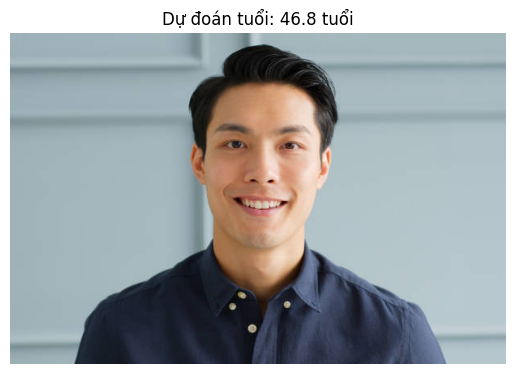

46.839787

In [58]:
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_age_from_url(img_url, model, target_size=(128, 128)):
    try:
        # 1. Tải ảnh từ URL
        response = requests.get(img_url)
        img = Image.open(BytesIO(response.content)).convert('RGB')

        # 2. Resize và chuẩn hóa ảnh
        img_resized = img.resize(target_size)
        img_array = image.img_to_array(img_resized) / 255.0  # scale về [0,1]
        img_array = np.expand_dims(img_array, axis=0)        # shape (1, H, W, 3)

        # 3. Dự đoán tuổi
        pred_age = model.predict(img_array, verbose=0).flatten()[0]

        # 4. Hiển thị ảnh + kết quả
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Dự đoán tuổi: {pred_age:.1f} tuổi")
        plt.show()
        
        return pred_age

    except Exception as e:
        print(f"Lỗi khi dự đoán từ URL: {e}")
        return None
img_url = "https://media.istockphoto.com/id/1288538088/vi/anh/ch%C3%A2n-dung-doanh-nh%C3%A2n-tr%E1%BA%BB-th%C3%B4ng-minh-ch%C3%A2u-%C3%A1-nh%C3%ACn-v%C3%A0o-m%C3%A1y-%E1%BA%A3nh-v%C3%A0-n%E1%BB%A5-c%C6%B0%E1%BB%9Di.jpg?s=612x612&w=0&k=20&c=x7tUzNPNFR2FFWvuBdRC5V0cu60WmTcOwq8wahnEzwo="
predict_age_from_url(img_url, model)